1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

2. Load Dataset

In [4]:
df = pd.read_csv("Customer_Churn_EDA_Gayathri.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


3. Dataset Overview

In [5]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Rows and Columns:
(7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn

4. Statistical Summary

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


5. Check Missing Values

In [7]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

6. Duplicate Check



In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print(df.shape)

(7043, 21)


7. Data Cleaning

In [10]:
df.columns = df.columns.str.strip()

In [11]:
for col in df.select_dtypes('object'):
    df[col] = df[col].str.strip()

8. Churn Column Check

In [12]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

CHART 1: Churn Count Plot

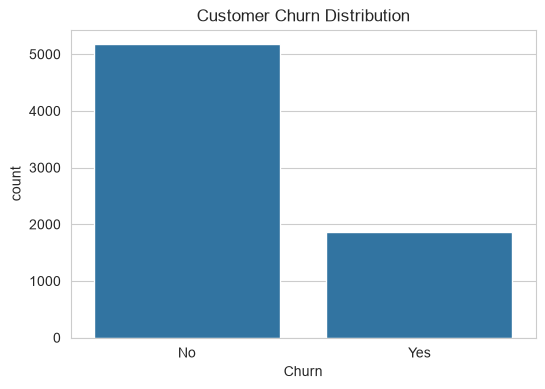

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

CHART 2: Churn Percentage Pie Chart

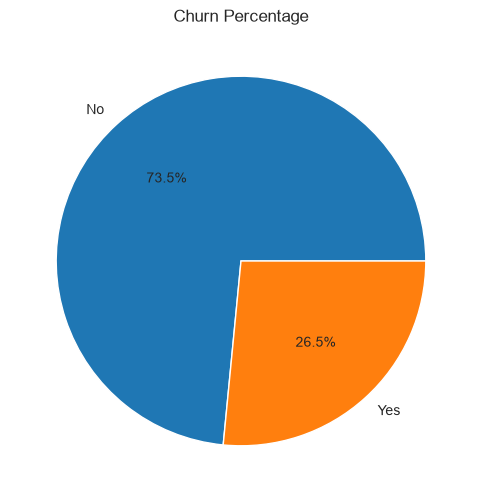

In [14]:
churn_percentage = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct='%1.1f%%'
)

plt.title("Churn Percentage")

plt.show()

CHART 3: Numerical Feature Histogram




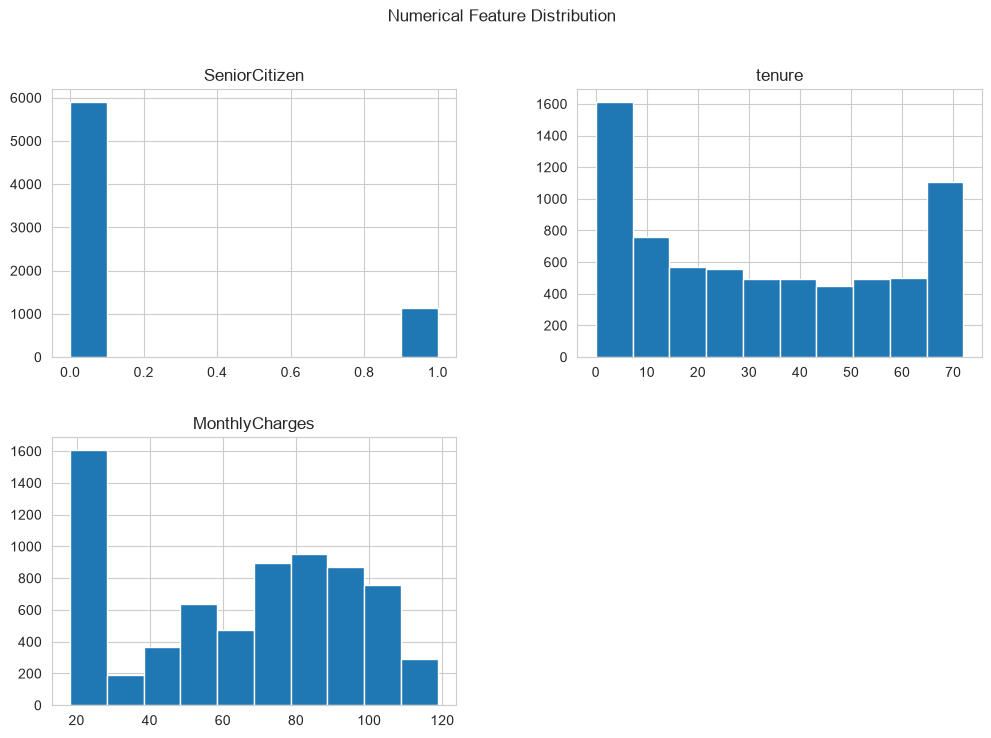

In [15]:
df.select_dtypes(include=np.number).hist(
    figsize=(12,8)
)

plt.suptitle("Numerical Feature Distribution")

plt.show()

CHART 4: Boxplot (Outlier Detection)

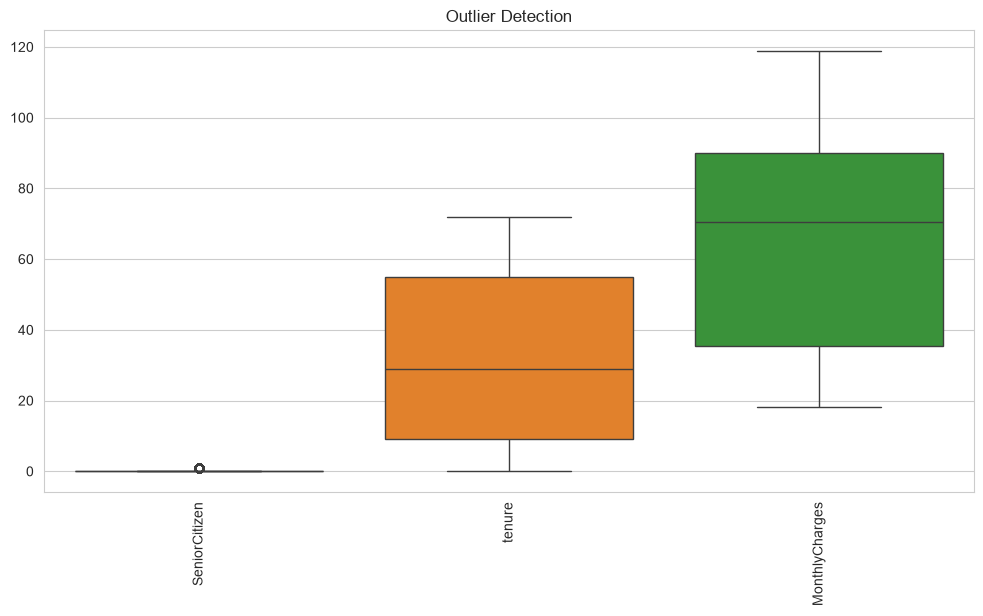

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[numeric_columns]
)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

CHART 5: Churn by Gender

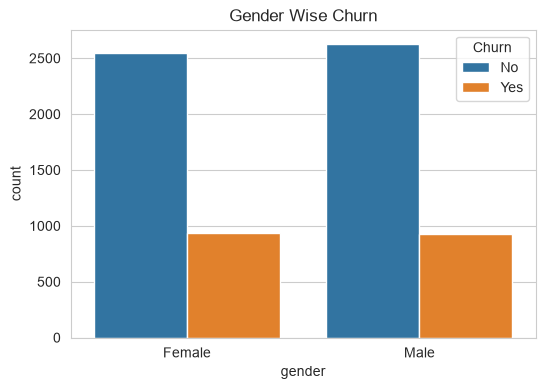

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender Wise Churn")

plt.show()

CHART 6: Churn by Contract / Category



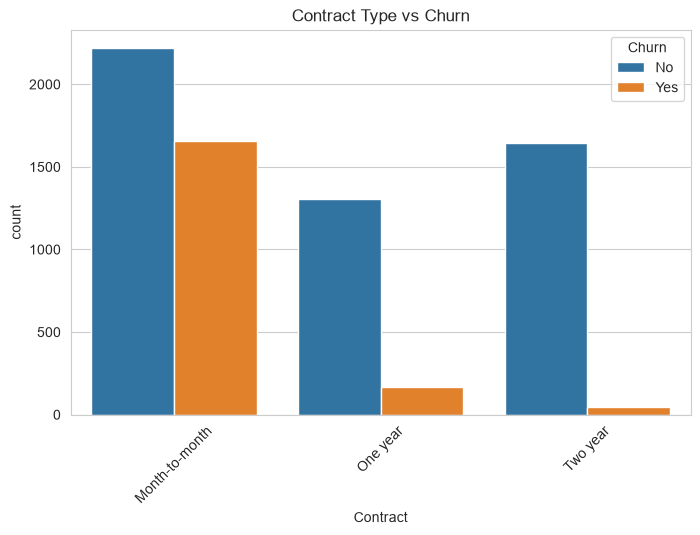

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=45)

plt.show()

CHART 7: Correlation Heatmap

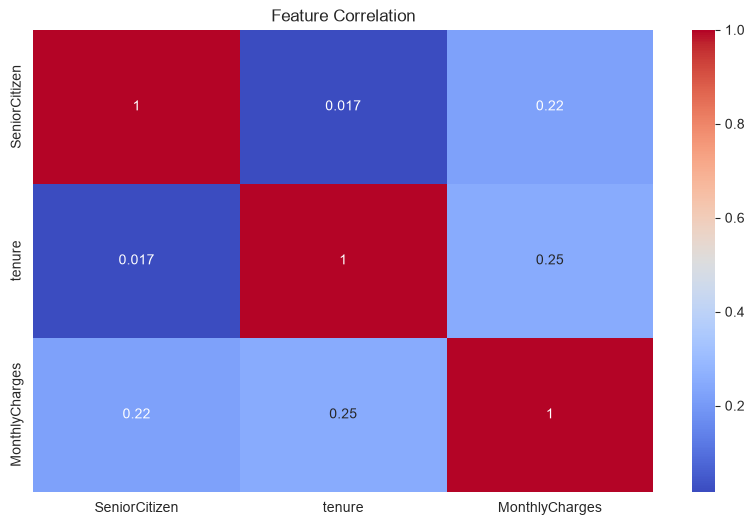

In [19]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(
    include=np.number
).corr()


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.title("Feature Correlation")

plt.show()

CHART 8: Scatter Plot


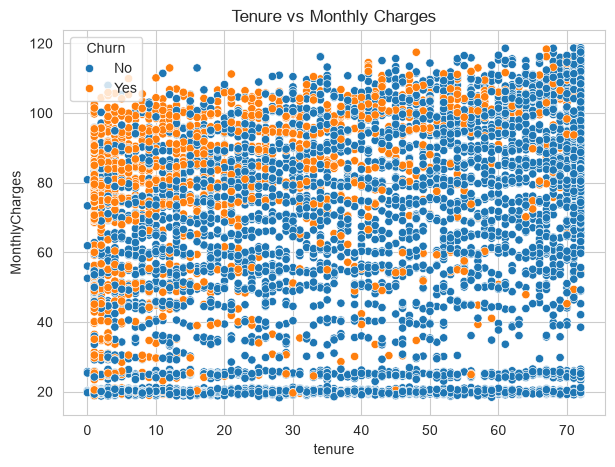

In [20]:
plt.figure(figsize=(7,5))


sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)


plt.title(
    "Tenure vs Monthly Charges"
)


plt.show()

9. Churn Rate by Categories

In [21]:
for col in df.select_dtypes('object').columns:

    if col != 'Churn':

        print("\n",col)

        print(
            pd.crosstab(
                df[col],
                df['Churn'],
                normalize='index'
            )*100
        )


 customerID
Churn          No    Yes
customerID              
0002-ORFBO  100.0    0.0
0003-MKNFE  100.0    0.0
0004-TLHLJ    0.0  100.0
0011-IGKFF    0.0  100.0
0013-EXCHZ    0.0  100.0
...           ...    ...
9987-LUTYD  100.0    0.0
9992-RRAMN    0.0  100.0
9992-UJOEL  100.0    0.0
9993-LHIEB  100.0    0.0
9995-HOTOH  100.0    0.0

[7043 rows x 2 columns]

 gender
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

 Partner
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

 Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

 PhoneService
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

 MultipleLines
Churn                    No        Yes
MultipleLines              

10. Save Cleaned Dataset

In [22]:
df.to_csv(
    "Cleaned_Customer_Churn_Dataset_S_Gayathri.csv",
    index=False
)

11. Final Insights Section (Markdown cell)

## Final Insights

1. The dataset was cleaned by handling missing values and duplicate records.

2. Churn distribution shows the percentage of customers leaving the service.

3. Certain customer groups have higher churn probability.

4. Numerical features such as tenure and charges show relationship with churn.

5. Contract type and service usage patterns influence customer retention.

## Recommendations

- Provide offers for high-risk customers.
- Improve customer support experience.
- Encourage long-term contracts.
- Identify churn patterns early using predictive models.